# CV Lab Exam: All Code (Labs 01-06)
One cell per topic. Run the setup cell first. Images are in `Data/`.

In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd

def show(imgs, titles=None, cols=None, size=4):
    """Show a list of images side by side. BGR (3-ch) is converted to RGB; 2D uses gray."""
    imgs = imgs if isinstance(imgs, list) else [imgs]
    cols = cols or len(imgs); rows = (len(imgs) + cols - 1) // cols
    plt.figure(figsize=(size * cols, size * rows))
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i + 1)
        if im.ndim == 3: plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else: plt.imshow(im, cmap='gray')
        if titles: plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout(); plt.show()

img = cv2.imread('Data/lena.jpg')
assert img is not None, 'image not found'
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = img.shape[:2]
print(img.shape, img.dtype)

(512, 512, 3) uint8


## Lab 01: Basics

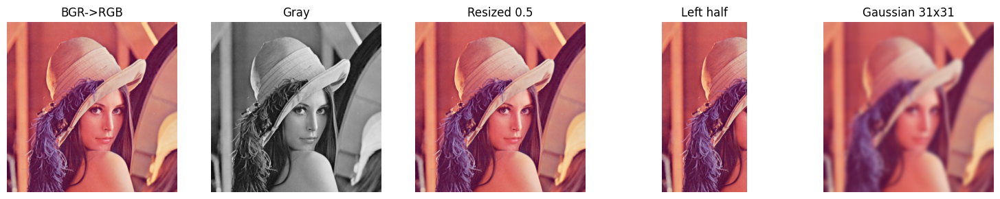

In [2]:
# Read / RGB / gray / resize / crop / blur
rgb_small = cv2.resize(img, None, fx=0.5, fy=0.5)          # or cv2.resize(img, (w, h)) -> dsize = (width, height)
crop = img[:, :w // 2]                                      # rows, cols -> left half
blur = cv2.GaussianBlur(img, (31, 31), 0)                   # kernel odd, sigma 0 = auto
show([img, gray, rgb_small, crop, blur], ['BGR->RGB', 'Gray', 'Resized 0.5', 'Left half', 'Gaussian 31x31'], cols=5, size=3)

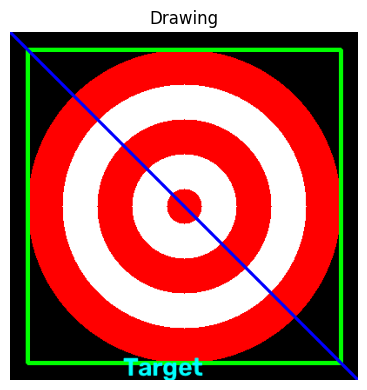

In [3]:
# Drawing + text on a canvas (thickness -1 = filled, color is BGR)
canvas = np.zeros((400, 400, 3), np.uint8)
for r, col in zip([180, 140, 100, 60, 20], [(0,0,255), (255,255,255)] * 2 + [(0,0,255)]):
    cv2.circle(canvas, (200, 200), r, col, -1)
cv2.rectangle(canvas, (20, 20), (380, 380), (0, 255, 0), 3)
cv2.line(canvas, (0, 0), (399, 399), (255, 0, 0), 2)
cv2.putText(canvas, 'Target', (130, 395), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2, cv2.LINE_AA)
show(canvas, ['Drawing'])

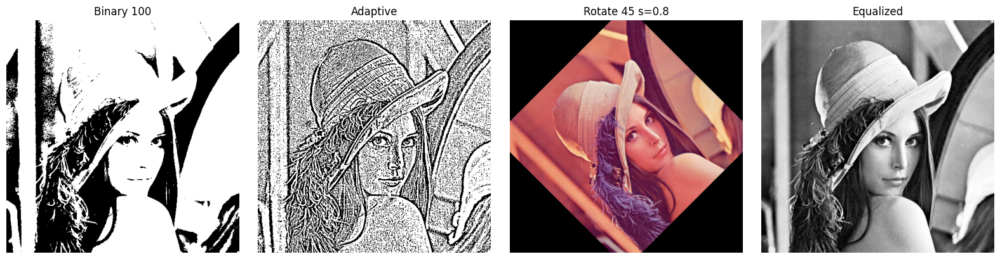

In [4]:
# Threshold (global vs adaptive), rotation, equalization
_, th = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)                     # returns (ret, img)
ad = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)  # returns img only
M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 0.8)                         # +angle = CCW, 2x3
rot = cv2.warpAffine(img, M, (w, h))
eq = cv2.equalizeHist(gray)
show([th, ad, rot, eq], ['Binary 100', 'Adaptive', 'Rotate 45 s=0.8', 'Equalized'])

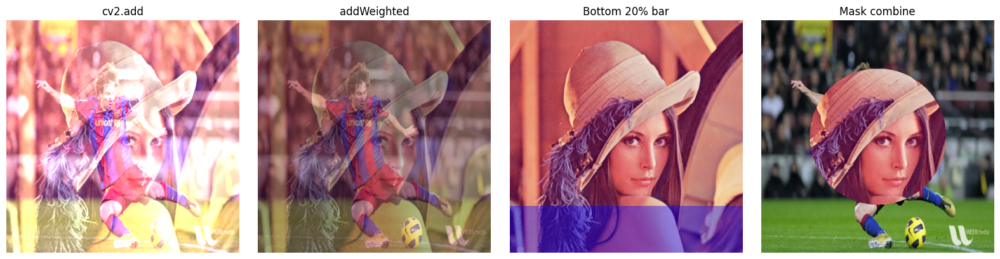

In [5]:
# Blending, overlay bar, bitwise masking
other = cv2.resize(cv2.imread('Data/messi5.jpg'), (w, h))
added = cv2.add(img, other)                                   # saturates at 255
blend = cv2.addWeighted(img, 0.5, other, 0.5, 0)              # a*img1 + b*img2 + g
bar = img.copy(); cv2.rectangle(bar, (0, int(h * 0.8)), (w, h), (255, 0, 0), -1)
overlay = cv2.addWeighted(img, 0.6, bar, 0.4, 0)
mask = np.zeros((h, w), np.uint8); cv2.circle(mask, (w // 2, h // 2), 150, 255, -1)
fg = cv2.bitwise_and(img, img, mask=mask)
bg = cv2.bitwise_and(other, other, mask=cv2.bitwise_not(mask))
combo = cv2.bitwise_or(fg, bg)
show([added, blend, overlay, combo], ['cv2.add', 'addWeighted', 'Bottom 20% bar', 'Mask combine'])

In [6]:
# Pandas stats of channels
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
df = pd.DataFrame(rgb.reshape(-1, 3), columns=['Red', 'Green', 'Blue'])
df.describe()

,Red,Green,Blue
count,262144.000000,262144.000000,262144.000000
mean,179.730305,99.562698,105.398991
std,49.015788,52.873559,33.742119
min,49.000000,0.000000,27.000000
25%,145.000000,60.000000,79.000000
50%,196.000000,98.000000,101.000000
75%,219.000000,135.000000,124.000000
max,255.000000,246.000000,222.000000


## Lab 02: Enhancement, fusion, video

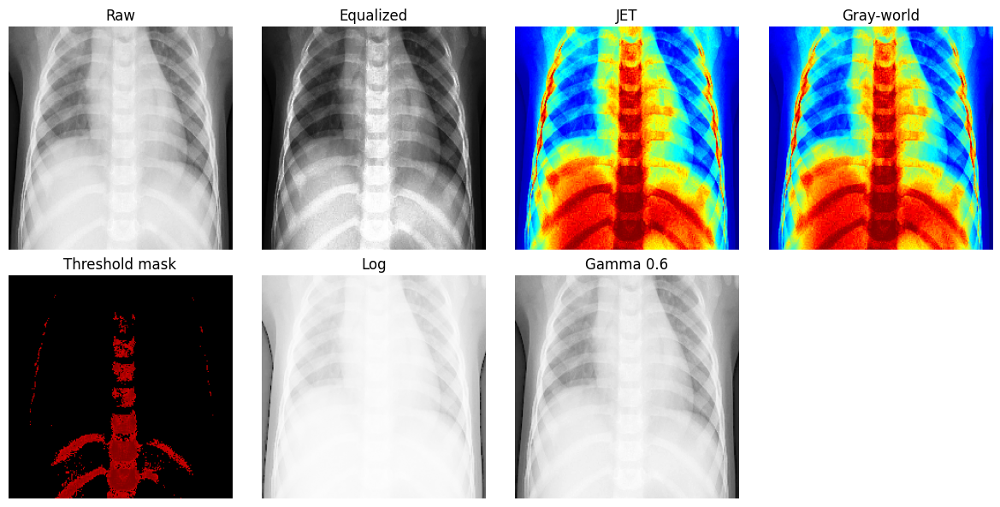

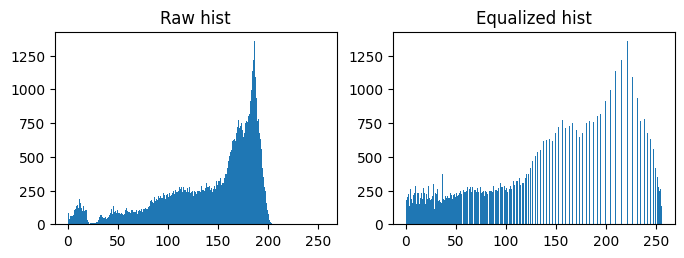

In [7]:
xray = cv2.imread('Data/sample_xray.png', cv2.IMREAD_GRAYSCALE)
eq = cv2.equalizeHist(xray)                                   # CDF-based contrast stretch
jet = cv2.applyColorMap(eq, cv2.COLORMAP_JET)                 # false color, 3-ch BGR

def gray_world(bgr):                                          # color balance
    f = bgr.astype(np.float64); m = f.reshape(-1, 3).mean(0)
    return np.clip(f * (m.mean() / m), 0, 255).astype(np.uint8)
bal = gray_world(jet)

T = np.percentile(eq, 90)                                     # densest 10%
_, dense = cv2.threshold(eq, T, 255, cv2.THRESH_BINARY)
dense_only = cv2.bitwise_and(jet, jet, mask=dense)

def log_t(im):  f = im.astype(np.float64); return np.clip(255 / np.log(1 + f.max()) * np.log(1 + f), 0, 255).astype(np.uint8)
def gamma_t(im, g): return np.clip(255 * np.power(im / 255.0, g), 0, 255).astype(np.uint8)

show([xray, eq, jet, bal, dense_only, log_t(xray), gamma_t(xray, 0.6)],
     ['Raw', 'Equalized', 'JET', 'Gray-world', 'Threshold mask', 'Log', 'Gamma 0.6'], cols=4, size=3)
plt.figure(figsize=(8, 2.5))
plt.subplot(121); plt.hist(xray.ravel(), 256, range=(0, 256)); plt.title('Raw hist')
plt.subplot(122); plt.hist(eq.ravel(), 256, range=(0, 256)); plt.title('Equalized hist'); plt.show()

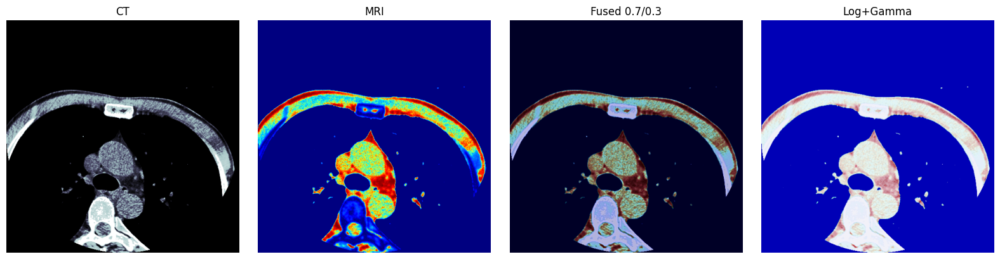

In [8]:
# CT + MRI weighted fusion
ct = cv2.equalizeHist(cv2.imread('Data/ct_slice.png', 0))
mri = cv2.equalizeHist(cv2.imread('Data/mri_slice.png', 0))
ct_c, mri_c = cv2.applyColorMap(ct, cv2.COLORMAP_BONE), cv2.applyColorMap(mri, cv2.COLORMAP_JET)
fused = cv2.addWeighted(ct_c, 0.7, mri_c, 0.3, 0)            # same size + channels required
final = gamma_t(log_t(fused), 0.8)
show([ct_c, mri_c, fused, final], ['CT', 'MRI', 'Fused 0.7/0.3', 'Log+Gamma'])

frames 215 fps 50.0


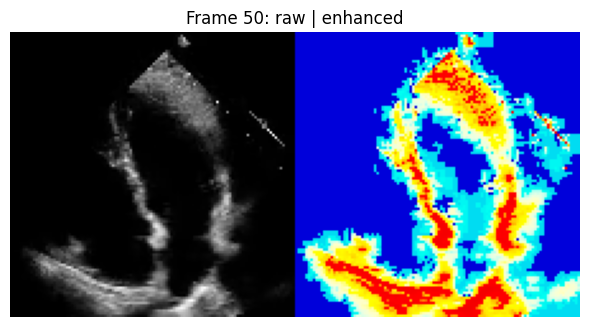

In [9]:
# Video loop: read -> enhance -> side by side
cap = cv2.VideoCapture('Data/echo_sample.mp4')
print('frames', int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), 'fps', cap.get(cv2.CAP_PROP_FPS))
shots = []
while True:
    ret, frame = cap.read()
    if not ret: break                                       # end of video
    g = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    enh = gamma_t(log_t(gray_world(cv2.applyColorMap(cv2.equalizeHist(g), cv2.COLORMAP_JET))), 0.7)
    combined = np.hstack([cv2.cvtColor(g, cv2.COLOR_GRAY2BGR), enh])   # same height + channels
    # cv2.imshow('Raw | Enhanced', combined)
    # if cv2.waitKey(1) & 0xFF == ord('q'): break
    if len(shots) < 1 and int(cap.get(cv2.CAP_PROP_POS_FRAMES)) == 50: shots.append(combined)
cap.release(); cv2.destroyAllWindows()
show(shots, ['Frame 50: raw | enhanced'], size=6)

## Lab 03: Geometric transformations

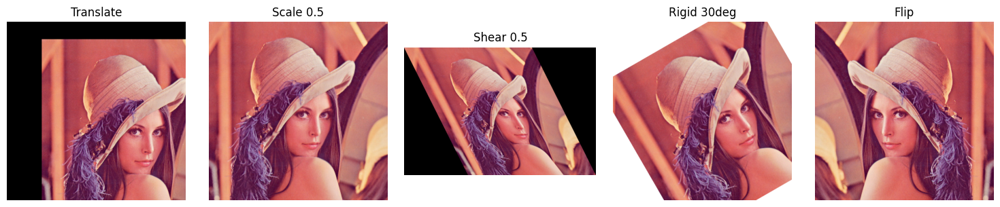

In [10]:
tx, ty = 100, 50
T = np.float32([[1, 0, tx], [0, 1, ty]])                       # +ty moves down
trans = cv2.warpAffine(img, T, (w, h))

scaled = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

k = 0.5                                                        # horizontal shear x' = x + k*y
sh = cv2.warpAffine(img, np.float32([[1, k, 0], [0, 1, 0]]), (int(w + k * h), h))

R = cv2.getRotationMatrix2D((w // 2, h // 2), 30, 1.0)         # rigid = rotate + translate, scale 1
R[0, 2] += 50; R[1, 2] += 20
rigid = cv2.warpAffine(img, R, (w, h), borderValue=(255, 255, 255))

flip = cv2.flip(img, 1)                                        # 0 vert, 1 horiz, -1 both
show([trans, scaled, sh, rigid, flip], ['Translate', 'Scale 0.5', 'Shear 0.5', 'Rigid 30deg', 'Flip'], cols=5, size=3)

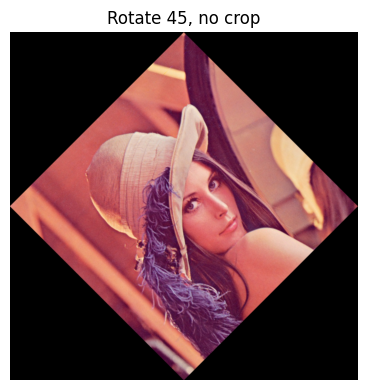

In [11]:
# Rotate without cropping corners
M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)
cos, sin = abs(M[0, 0]), abs(M[0, 1])
nW, nH = int(h * sin + w * cos), int(h * cos + w * sin)
M[0, 2] += nW / 2 - w / 2; M[1, 2] += nH / 2 - h / 2
show(cv2.warpAffine(img, M, (nW, nH)), ['Rotate 45, no crop'])

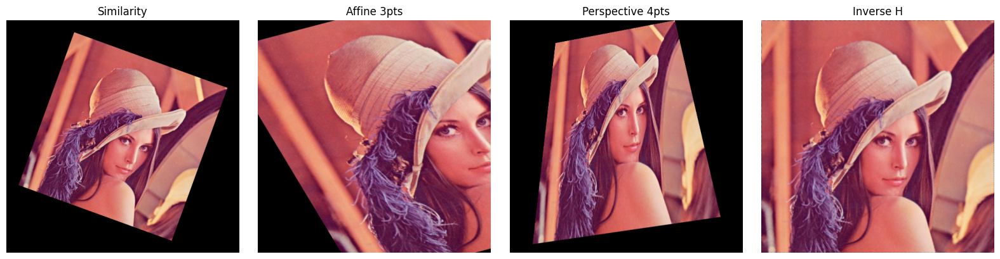

In [12]:
# Homogeneous 3x3 composition (rightmost applied first) and manual rotation matrix
def Tm(tx, ty): return np.float32([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
def Rm(deg):  t = np.radians(deg); return np.float32([[np.cos(t), -np.sin(t), 0], [np.sin(t), np.cos(t), 0], [0, 0, 1]])
def Sm(s):    return np.float32([[s, 0, 0], [0, s, 0], [0, 0, 1]])
cx, cy = w / 2, h / 2
M3 = Tm(cx, cy) @ Rm(20) @ Sm(0.7) @ Tm(-cx, -cy)           # similarity about the center
sim = cv2.warpAffine(img, M3[:2], (w, h))                    # warpAffine needs 2x3

# General affine from 3 point pairs, perspective from 4
src3 = np.float32([[50, 50], [200, 50], [50, 200]]); dst3 = np.float32([[10, 100], [200, 50], [100, 250]])
aff = cv2.warpAffine(img, cv2.getAffineTransform(src3, dst3), (w, h))
src4 = np.float32([[0, 0], [w - 1, 0], [w - 1, h - 1], [0, h - 1]])          # TL TR BR BL
dst4 = np.float32([[100, 50], [w - 150, 0], [w - 50, h - 80], [50, h - 20]])
H = cv2.getPerspectiveTransform(src4, dst4)                   # 3x3
persp = cv2.warpPerspective(img, H, (w, h))
back = cv2.warpPerspective(persp, np.linalg.inv(H), (w, h))   # undo
show([sim, aff, persp, back], ['Similarity', 'Affine 3pts', 'Perspective 4pts', 'Inverse H'])

## Lab 04: Feature extraction, filtering, edges

HOG vector length (142884,)


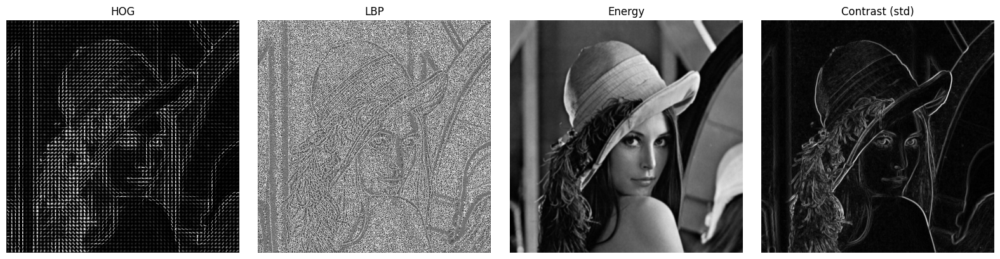

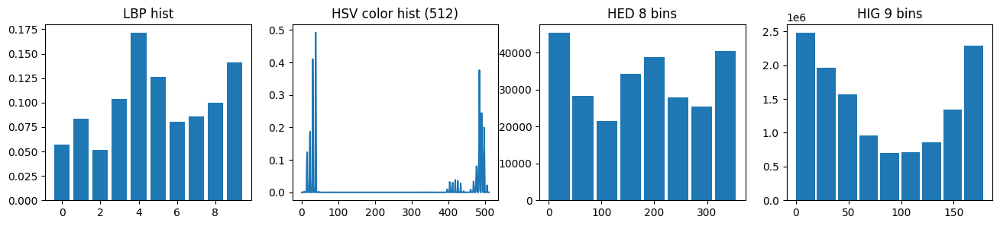

In [13]:
from skimage.feature import hog, local_binary_pattern
from skimage import exposure

feat, hog_img = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
print('HOG vector length', feat.shape)

lbp = local_binary_pattern(gray, 8, 1, method='uniform')        # codes 0..9
lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11)); lbp_hist = lbp_hist / lbp_hist.sum()

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
color_hist = cv2.normalize(cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256]), None).flatten()

gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3); gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
mag = np.sqrt(gx**2 + gy**2); ang = np.degrees(np.arctan2(gy, gx))      # -180..180
hed, _ = np.histogram(ang % 360, bins=8, range=(0, 360))                 # HED
hig, _ = np.histogram(ang % 180, bins=9, range=(0, 180), weights=mag)    # HIG

f = gray.astype(np.float32)                                             # texture energy / contrast
energy = cv2.boxFilter(f * f, -1, (3, 3), normalize=False)
contrast = np.sqrt(np.maximum(cv2.blur(f * f, (3, 3)) - cv2.blur(f, (3, 3))**2, 0))

show([exposure.rescale_intensity(hog_img, in_range=(0, 10)), lbp, energy, contrast], ['HOG', 'LBP', 'Energy', 'Contrast (std)'])
fig, ax = plt.subplots(1, 4, figsize=(16, 3))
ax[0].bar(range(10), lbp_hist); ax[0].set_title('LBP hist')
ax[1].plot(color_hist); ax[1].set_title('HSV color hist (512)')
ax[2].bar(range(0, 360, 45), hed, width=40, align='edge'); ax[2].set_title('HED 8 bins')
ax[3].bar(range(0, 180, 20), hig, width=18, align='edge'); ax[3].set_title('HIG 9 bins'); plt.show()

same (512, 512) valid (510, 510) stride2 (256, 256)


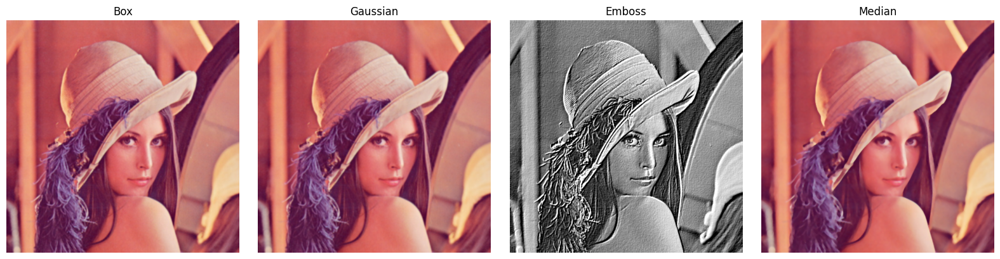

In [14]:
# Convolution / filters
box = cv2.filter2D(img, -1, np.ones((3, 3), np.float32) / 9)            # -1 = same depth
g1 = cv2.getGaussianKernel(5, 1.0); gauss = cv2.filter2D(img, -1, g1 @ g1.T)   # 5x1 -> 5x5
emboss = cv2.filter2D(gray, -1, np.float32([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]]))
med = cv2.medianBlur(img, 5)
sobel_k = np.float32([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
same = cv2.filter2D(gray, -1, sobel_k, borderType=cv2.BORDER_CONSTANT)  # zero padding, same size
valid = same[1:-1, 1:-1]                                                 # valid = crop k//2
strided = same[::2, ::2]                                                 # stride 2
print('same', same.shape, 'valid', valid.shape, 'stride2', strided.shape)
show([box, gauss, emboss, med], ['Box', 'Gaussian', 'Emboss', 'Median'])

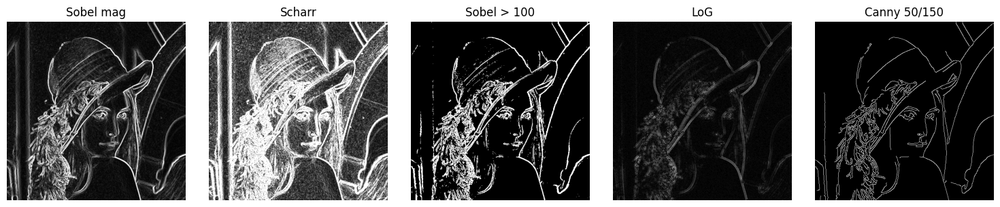

In [15]:
# Edges: Sobel, Scharr, LoG, Canny
sob = cv2.convertScaleAbs(np.sqrt(gx**2 + gy**2))
sch = cv2.convertScaleAbs(cv2.magnitude(cv2.Scharr(gray, cv2.CV_64F, 1, 0), cv2.Scharr(gray, cv2.CV_64F, 0, 1)))
thr_edges = (np.sqrt(gx**2 + gy**2) > 100).astype(np.uint8) * 255
log_edges = cv2.convertScaleAbs(cv2.Laplacian(cv2.GaussianBlur(gray, (5, 5), 1.4), cv2.CV_64F))
canny = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 1.4), 50, 150)          # low, high
show([sob, sch, thr_edges, log_edges, canny], ['Sobel mag', 'Scharr', 'Sobel > 100', 'LoG', 'Canny 50/150'], cols=5, size=3)

## Lab 05: Segmentation

Otsu threshold = 162.0


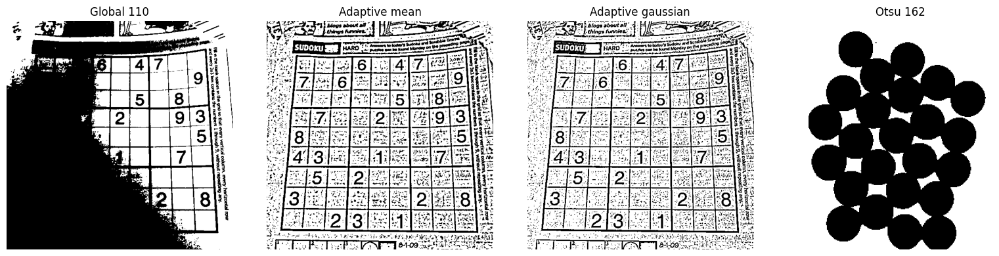

In [16]:
sud = cv2.imread('Data/sudoku.png', 0)
_, g1 = cv2.threshold(sud, 110, 255, cv2.THRESH_BINARY)
m = cv2.adaptiveThreshold(sud, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
gs = cv2.adaptiveThreshold(sud, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
coins = cv2.imread('Data/coins.jpg'); cg = cv2.cvtColor(coins, cv2.COLOR_BGR2GRAY)
t, otsu = cv2.threshold(cg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)   # t = auto threshold
print('Otsu threshold =', t)
show([g1, m, gs, otsu], ['Global 110', 'Adaptive mean', 'Adaptive gaussian', f'Otsu {t:.0f}'])

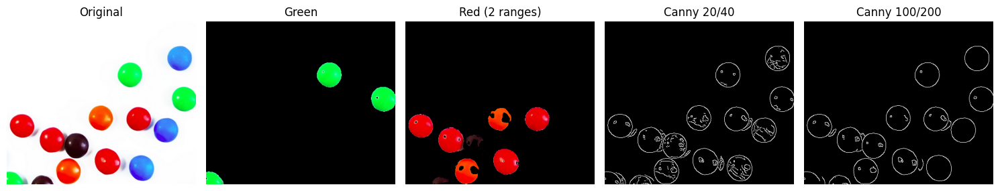

In [17]:
# HSV color segmentation + Canny thresholds
sm = cv2.imread('Data/smarties.png'); hsv = cv2.cvtColor(sm, cv2.COLOR_BGR2HSV)
green = cv2.inRange(hsv, np.array([40, 80, 40]), np.array([85, 255, 255]))        # H 0-179
red = cv2.inRange(hsv, (0, 100, 50), (10, 255, 255)) | cv2.inRange(hsv, (170, 100, 50), (179, 255, 255))
gsm = cv2.cvtColor(sm, cv2.COLOR_BGR2GRAY)
show([sm, cv2.bitwise_and(sm, sm, mask=green), cv2.bitwise_and(sm, sm, mask=red),
      cv2.Canny(gsm, 20, 40), cv2.Canny(gsm, 100, 200)], ['Original', 'Green', 'Red (2 ranges)', 'Canny 20/40', 'Canny 100/200'], cols=5, size=3)

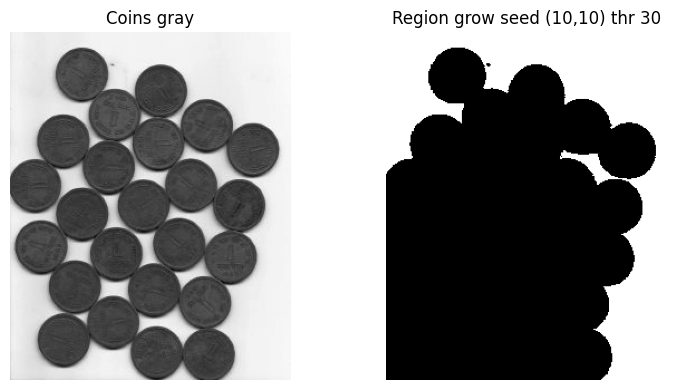

In [18]:
# Region growing from a seed
from collections import deque
def region_grow(im, seed, thr):
    mask = np.zeros_like(im, np.uint8); sv = int(im[seed]); q = deque([seed])
    while q:
        r, c = q.popleft()
        if 0 <= r < im.shape[0] and 0 <= c < im.shape[1] and mask[r, c] == 0 and abs(int(im[r, c]) - sv) < thr:
            mask[r, c] = 255
            q.extend([(r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)])        # 4-connectivity
    return mask
show([cg, region_grow(cg, (10, 10), 30)], ['Coins gray', 'Region grow seed (10,10) thr 30'])

coins found: 24


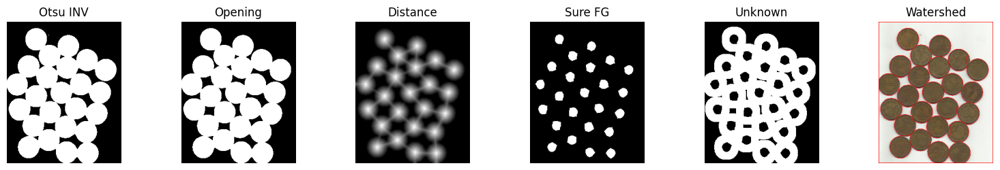

In [19]:
# Marker-based watershed on touching coins
img_w = coins.copy()
_, th = cv2.threshold(cg, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=2)     # remove noise
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.6 * dist.max(), 255, 0); sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
n, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1; markers[unknown == 255] = 0                       # bg=1, unknown=0
markers = cv2.watershed(img_w, markers)                                  # boundaries = -1
img_w[markers == -1] = [0, 0, 255]
print('coins found:', n - 1)
show([th, opening, cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), sure_fg, unknown, img_w],
     ['Otsu INV', 'Opening', 'Distance', 'Sure FG', 'Unknown', 'Watershed'], cols=6, size=2.6)

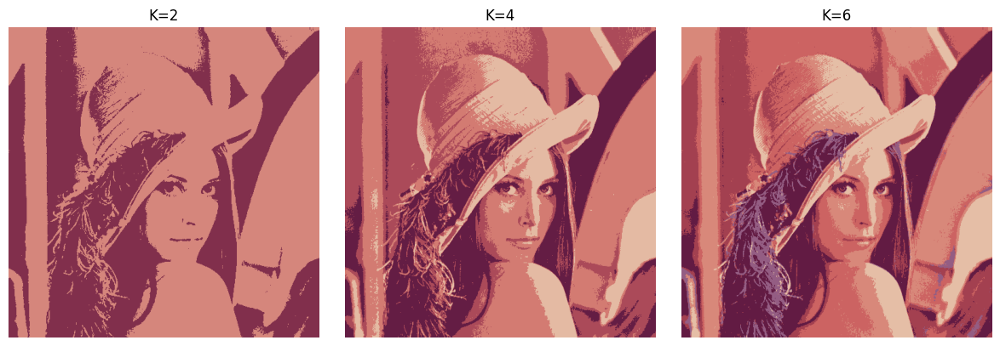

In [20]:
# K-Means color segmentation
px = np.float32(img.reshape(-1, 3))
crit = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
outs = []
for K in (2, 4, 6):
    _, labels, centers = cv2.kmeans(px, K, None, crit, 10, cv2.KMEANS_RANDOM_CENTERS)
    outs.append(np.uint8(centers)[labels.flatten()].reshape(img.shape))
show(outs, ['K=2', 'K=4', 'K=6'])

## Lab 06: Wavelets, Hough, SIFT, video

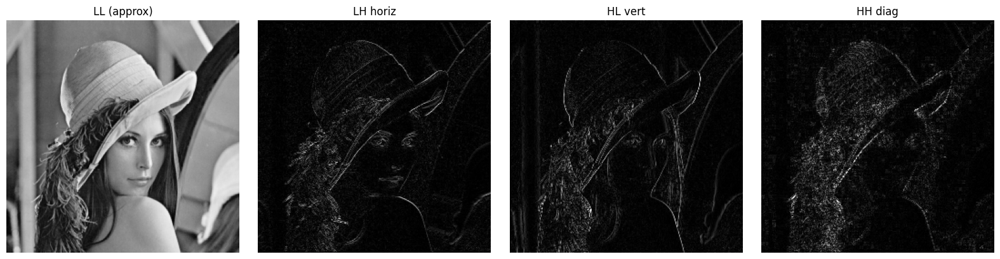

anomalies at [200 219 303 478 600 850]


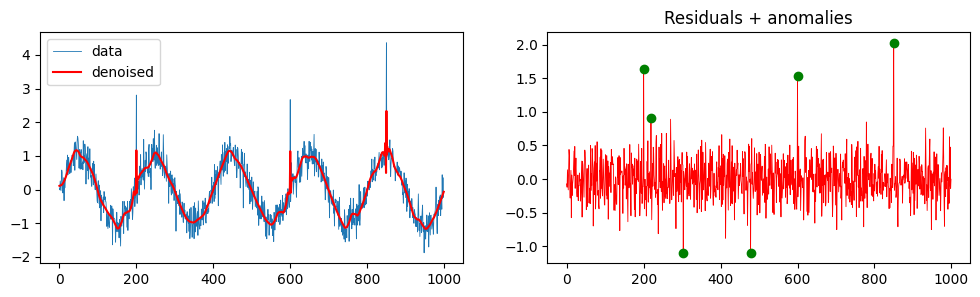

In [21]:
import pywt
cA, (cH, cV, cD) = pywt.dwt2(gray, 'haar')                       # 1-level 2D DWT
show([cA, np.abs(cH), np.abs(cV), np.abs(cD)], ['LL (approx)', 'LH horiz', 'HL vert', 'HH diag'])

# 1D denoising + anomaly detection
rng = np.random.default_rng(0); t = np.linspace(0, 1, 1000)
clean = np.sin(2 * np.pi * 5 * t); data = clean + 0.3 * rng.standard_normal(1000); data[[200, 600, 850]] += 3
coeffs = pywt.wavedec(data, 'db4', level=4)                      # [cA4, cD4, cD3, cD2, cD1]
sigma = np.median(np.abs(coeffs[-1])) / 0.6745; thr = sigma * np.sqrt(2 * np.log(len(data)))
coeffs[1:] = [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]   # details only
den = pywt.waverec(coeffs, 'db4')[:len(data)]
res = data - den; anom = np.where(np.abs(res) > 3 * np.std(res))[0]
print('anomalies at', anom)
plt.figure(figsize=(12, 3)); plt.subplot(121); plt.plot(data, lw=.6, label='data'); plt.plot(den, 'r', label='denoised'); plt.legend()
plt.subplot(122); plt.plot(res, 'r', lw=.6); plt.plot(anom, res[anom], 'go'); plt.title('Residuals + anomalies'); plt.show()

coins counted: 24


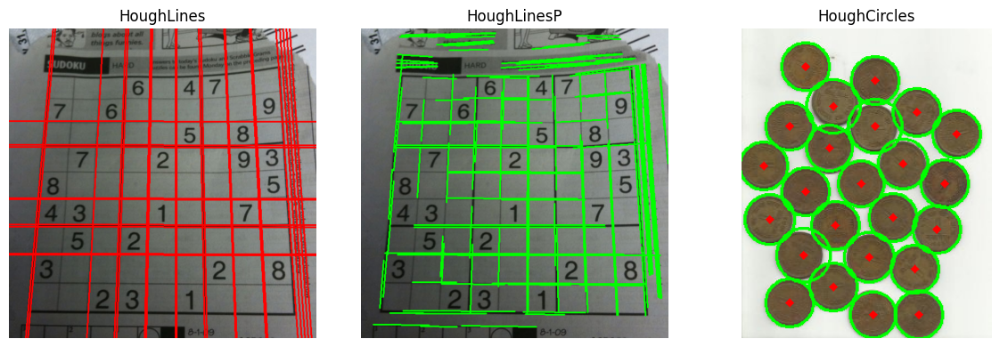

In [22]:
# Hough lines (standard + probabilistic) and circles
sud_c = cv2.imread('Data/sudoku.png'); sg = cv2.cvtColor(sud_c, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(sg, 50, 150, apertureSize=3)
std_img, p_img = sud_c.copy(), sud_c.copy()
lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)               # rho px, theta rad, votes
if lines is not None:
    for rho, theta in lines.reshape(-1, 2):           # works in OpenCV 4 (N,1,2) and 5 (N,2)
        a, b = np.cos(theta), np.sin(theta); x0, y0 = a * rho, b * rho
        cv2.line(std_img, (int(x0 - 1000 * b), int(y0 + 1000 * a)), (int(x0 + 1000 * b), int(y0 - 1000 * a)), (0, 0, 255), 2)
linesP = cv2.HoughLinesP(edges, 1, np.pi / 180, 80, minLineLength=60, maxLineGap=10)
if linesP is not None:
    for x1, y1, x2, y2 in linesP.reshape(-1, 4): cv2.line(p_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

c_img = coins.copy()
circles = cv2.HoughCircles(cv2.medianBlur(cg, 5), cv2.HOUGH_GRADIENT, dp=1, minDist=28, param1=50, param2=18, minRadius=15, maxRadius=35)
if circles is not None:
    circles = np.uint16(np.around(circles)).reshape(-1, 3)   # OpenCV 4 gives (1,N,3) -> (N,3)
    for x, y, r in circles: cv2.circle(c_img, (x, y), r, (0, 255, 0), 2); cv2.circle(c_img, (x, y), 2, (0, 0, 255), 3)
    print('coins counted:', len(circles))
show([std_img, p_img, c_img], ['HoughLines', 'HoughLinesP', 'HoughCircles'])

keypoints 604 969 descriptor (604, 128)
good matches 80 inliers 75


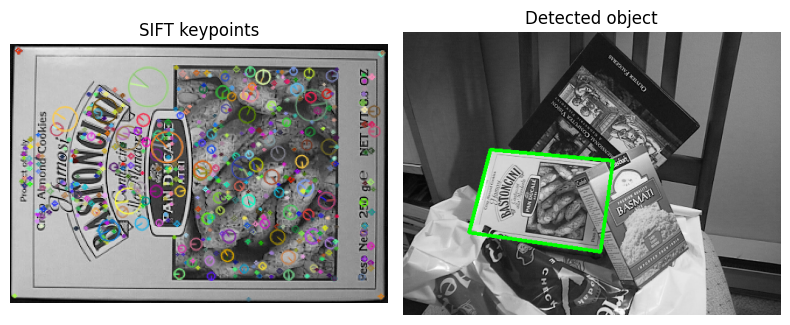

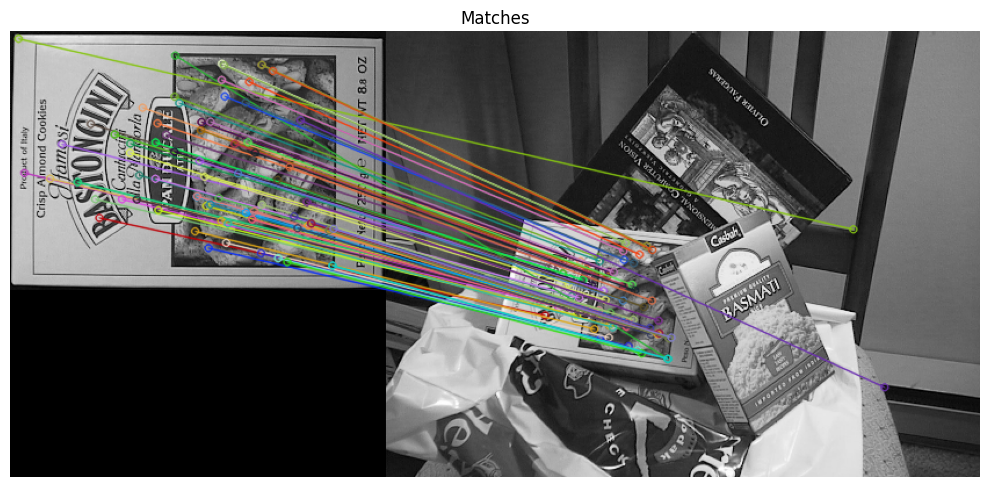

In [23]:
# SIFT keypoints + ratio test + RANSAC homography -> box around object
ref = cv2.imread('Data/box.png', 0); scene = cv2.imread('Data/box_in_scene.png', 0)
sift = cv2.SIFT_create()
k1, d1 = sift.detectAndCompute(ref, None); k2, d2 = sift.detectAndCompute(scene, None)
print('keypoints', len(k1), len(k2), 'descriptor', d1.shape)            # (N, 128)
kp_img = cv2.drawKeypoints(ref, k1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

good = [m for m, n in cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2) if m.distance < 0.75 * n.distance]
src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)                  # needs >= 4 pairs
hh, ww = ref.shape
box = cv2.perspectiveTransform(np.float32([[0, 0], [ww, 0], [ww, hh], [0, hh]]).reshape(-1, 1, 2), H)
scene_box = cv2.polylines(cv2.cvtColor(scene, cv2.COLOR_GRAY2BGR), [np.int32(box)], True, (0, 255, 0), 3)
matches = cv2.drawMatches(ref, k1, scene, k2, good, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
print('good matches', len(good), 'inliers', int(mask.sum()))
show([kp_img, scene_box], ['SIFT keypoints', 'Detected object'])
show(matches, ['Matches'], size=10)

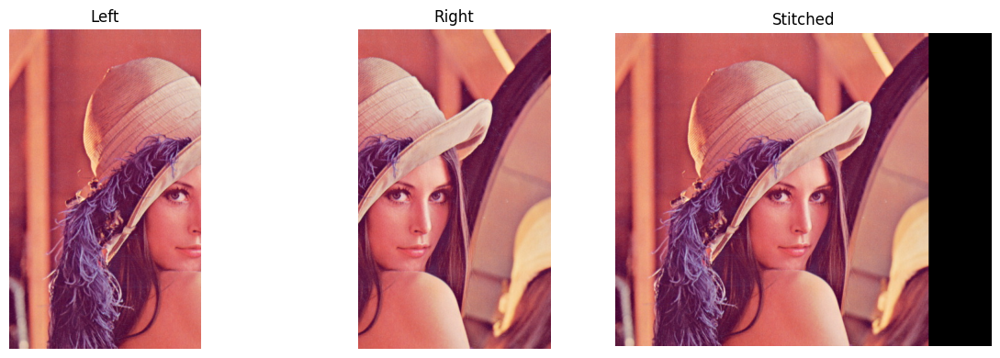

In [24]:
# Panorama: warp right image into left image's frame (made from one image for demo)
left, right = img[:, :int(w * 0.6)], img[:, int(w * 0.4):]
kL, dL = sift.detectAndCompute(cv2.cvtColor(left, cv2.COLOR_BGR2GRAY), None)
kR, dR = sift.detectAndCompute(cv2.cvtColor(right, cv2.COLOR_BGR2GRAY), None)
good = [m for m, n in cv2.BFMatcher().knnMatch(dR, dL, k=2) if m.distance < 0.75 * n.distance]
src = np.float32([kR[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst = np.float32([kL[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H, _ = cv2.findHomography(src, dst, cv2.RANSAC, 4.0)
pano = cv2.warpPerspective(right, H, (left.shape[1] + right.shape[1], h))
pano[:, :left.shape[1]] = left
show([left, right, pano], ['Left', 'Right', 'Stitched'])
# shortcut: status, pano = cv2.Stitcher_create().stitch([img1, img2])   # status 0 = OK

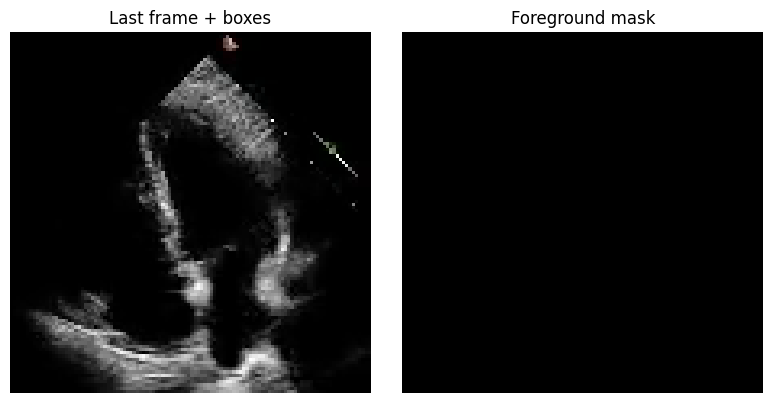

In [25]:
# Video: background subtraction + contours + VideoWriter
cap = cv2.VideoCapture('Data/echo_sample.mp4')
fw, fh, fps = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)), cap.get(cv2.CAP_PROP_FPS)
out = cv2.VideoWriter('output_demo.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (fw, fh))   # size must match frames
bg = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)
last = None
while True:
    ok, frame = cap.read()
    if not ok: break
    fgm = bg.apply(frame)                                                    # 255 fg, 127 shadow, 0 bg
    fgm = cv2.threshold(fgm, 200, 255, cv2.THRESH_BINARY)[1]
    fgm = cv2.morphologyEx(fgm, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))
    cnts, _ = cv2.findContours(fgm, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # OpenCV 4: 2 values
    for c in cnts:
        if cv2.contourArea(c) < 100: continue
        x, y, bw, bh = cv2.boundingRect(c); cv2.rectangle(frame, (x, y), (x + bw, y + bh), (0, 255, 0), 1)
    out.write(frame); last = (frame, fgm)
cap.release(); out.release()
show([last[0], last[1]], ['Last frame + boxes', 'Foreground mask'])